In [1]:
import numpy as np
import matplotlib.pyplot as plt
import string
import os

plt.rcParams.update(
    {
        "font.size": 11,  # base font size (tick labels)
        "axes.labelsize": 13,  # axis labels
        "axes.titlesize": 13,
        "legend.fontsize": 11,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "figure.dpi": 300,
    }
)

import jax.numpy as jnp
import jax

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_default_device", jax.devices("cpu")[0])

# Import your optimization and plotting utilities
from optimization_core import (
    build_jsa_grid,
    penalty_continuation_grad_desc,
    load_results,
    to_complex,
)

In [2]:
# ---------------------------------------------------------
# 1. Experiment parameters
# ---------------------------------------------------------

# Parameters for the multivariate normal distribution
n = 20  # Number of points in the frequency grid nxnxn
d = 6  # Dimensionality of the problem
mean = jnp.zeros(d)  # Mean
x_lim = 2.5  # Limits in x and y ax0is for plotting
omf = jnp.linspace(-x_lim, x_lim, n)

# # # Sweep parameters
n_steps = 36  # Number of steps in the sweep
rho_values = jnp.linspace(
    -0.19, 0.99, n_steps
)  # rho_values is analogous to the correlation coefficients in the correlation matrix

In [3]:
def T_vv(T, v):
    """Compute T(v,v,v,v,v) -> vector of shape (n,)."""
    return jnp.einsum("ijklmn,j,k,l,m,n->i", T, v, v, v, v, v)


def f_val(T, v):
    """Form f(v) = T(v,v,v,v,v,v)."""
    return jnp.einsum("ijklmn,i,j,k,l,m,n->", T, v, v, v, v, v, v)


def residual_norm(T, v):
    """Compute || T(v,v) - f(v) v || (should be ~0 for eigenvector)."""
    v = v / jnp.linalg.norm(v)
    vt = T_vv(T, v)
    f = f_val(T, v)
    return jnp.linalg.norm(vt - f * v)

In [4]:
residual_list = []
max_eigenvalue_list = []
overlap_list = []

In [5]:
for i, rho_value in enumerate(rho_values):
    # ---------------------------------------------------------
    # 1. Export data
    # ---------------------------------------------------------
    filename = f"eigen_eval_results_{d}D_20260617_r_{rho_value:.2f}.pkl"
    if os.path.exists("results_data/" + filename):
        df, _, _ = load_results(filename)
        v = to_complex(df["optim_lo"])
        v = v / jnp.linalg.norm(v)
        f_v = df["eta"]

        print("Building JSA grid...")
        _, jsa_data = build_jsa_grid(n, mean, rho_value, x_lim)

        f = f_val(jsa_data, v)
        res = residual_norm(jsa_data, v)

        residual_list.append(res)
        max_eigenvalue_list.append(f)
        overlap_list.append(f_v)

residuals = np.array(residual_list)
max_eigenvalues = np.array(max_eigenvalue_list)
overlaps = np.array(overlap_list)

Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...


In [6]:
np.savez(
    f"residuals_eigen_cond_{d}D.npz",
    rho_values=rho_values,
    residuals=residuals,
    max_eigenvalues=max_eigenvalues,
    overlaps=overlaps,
)

In [7]:
# data=np.load(f'residuals_eigen_cond_{d}D.npz')
# rho_values=data['rho_values']
# tauf=data['tauf']
# residuals=data['residual']
# residuals=data['residuals']
# overlaps=data['overlaps']

/home/gisell/miniconda3/envs/lo_optim2/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/gisell/miniconda3/envs/lo_optim2/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


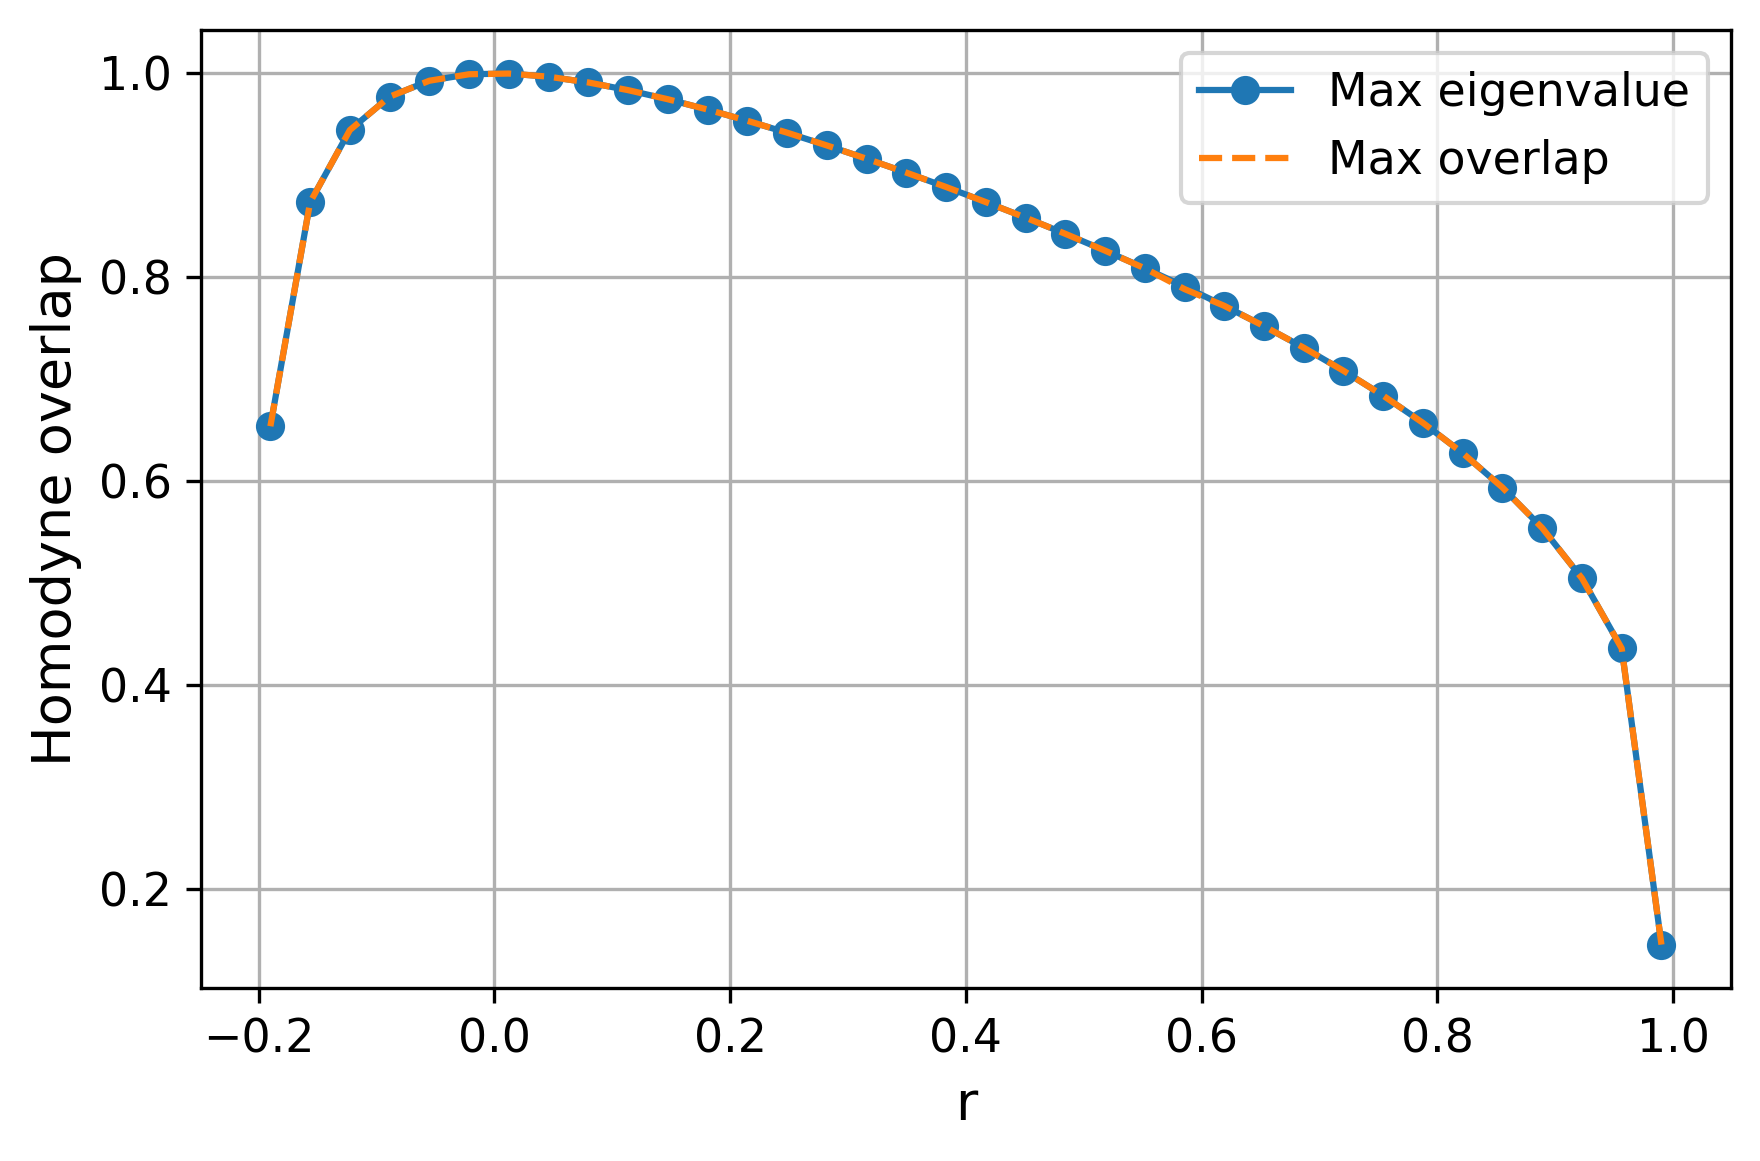

In [8]:
plt.figure(figsize=(6, 4))
plt.plot(rho_values, max_eigenvalues, "o-", label="Max eigenvalue")
plt.plot(rho_values, overlaps, "--", label="Max overlap")
plt.xlabel(r"r")
plt.ylabel("Homodyne overlap")
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.savefig(f'r_overlap_{d}D.pdf', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_1425089/1162628937.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


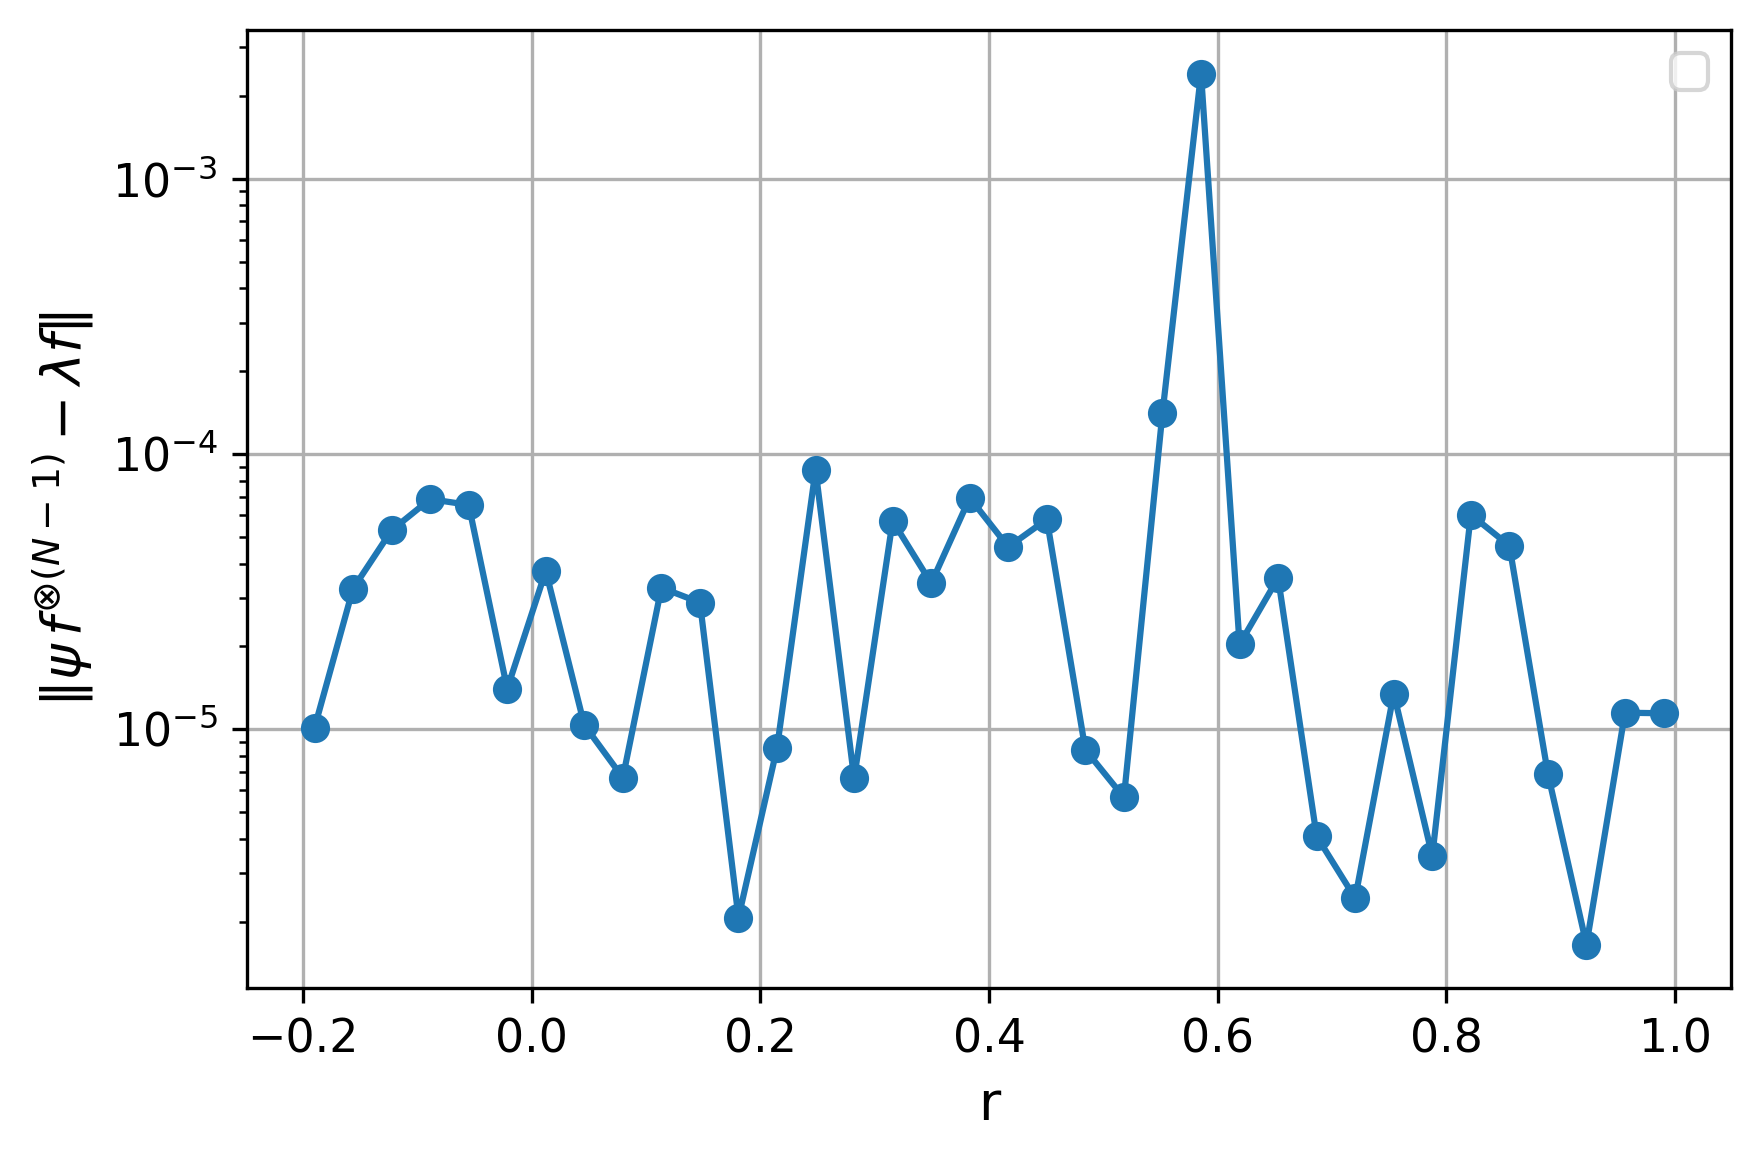

In [9]:
# --- Plot comparison ---
plt.figure(figsize=(6, 4))
plt.semilogy(rho_values, residuals, "o-")
plt.xlabel(r"r")
plt.ylabel(r"$\|\psi\,f^{\otimes (N-1)} - \lambda f\|$")
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.savefig(f'r_overlap_{d}D.pdf', dpi=300, bbox_inches='tight')
plt.show()